# Sprint 2: Wind turbine power curve analysis

Key facts about dataset:
- 72,577 timestamps
- 260 variables
- 10-minute resolution
- ~1.4 years of data
- 42 turbine positions (A1–F7 grid)
- 40 turbines with power measurements
- Met mast data available

Data has been checked for:
- time resolution ✔
- missing data ✔
- QC flags ✔
- physical sanity ✔
- wind–power relationship ✔

## Planned workflow
1. Select wind turbine (for example f7 since its on a border and experience less wake effect and power curve is cleaner)
2. Data filtering
    - Remove:
        - Missing values
        - QC flagged values
3. Scatter plot (SCADA cloud)
4. Wind speed binning
5. Empirical curve plot

## Step 1: Extracting data for slected wind turbine


In [4]:
import xarray as xr
import numpy as np

ds = xr.open_dataset('../data/norre_m2_all.nc')
df = ds[[
    'f7_pow',
    'f7_wsn',
    'f7_pow_qc',
    'f7_wsn_qc'
]].to_dataframe()

df.head()


,f7_pow,f7_wsn,f7_pow_qc,f7_wsn_qc
time,,,,
1991-12-22 23:36:00,113.5,NaN,0.0,NaN
1991-12-22 23:46:00,98.9,NaN,0.0,NaN
1991-12-22 23:56:00,78.6,NaN,0.0,NaN
1991-12-23 00:06:00,113.8,NaN,0.0,NaN
1991-12-23 00:16:00,128.9,NaN,0.0,NaN


### Clean dataset
For power curve analysis must have:
- Wind speed
- Power

In [5]:
df_clean = df.dropna()
df_clean.head()
print(df_clean.describe())
len(df),len(df_clean)

             f7_pow        f7_wsn  f7_pow_qc  f7_wsn_qc
count  20692.000000  20692.000000    20692.0    20692.0
mean     108.450952      9.004216        0.0        0.0
std       83.249705      2.696254        0.0        0.0
min       -5.300000      4.640000        0.0        0.0
25%       41.000000      6.960000        0.0        0.0
50%       84.400000      8.410000        0.0        0.0
75%      159.600000     10.470000        0.0        0.0
max      345.400000     23.160000        0.0        0.0


(72577, 20692)

We have 72577/20692 ratio of usable data so ~28%, meaning that around 72% data is missing. 20k points although is still enough for a power curve.

### 3. Scada power curve plot

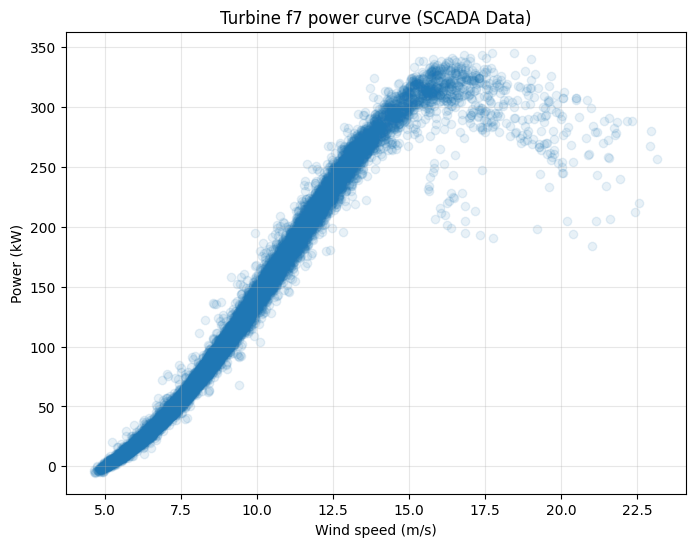

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_clean['f7_wsn'],
    df_clean['f7_pow'],
    alpha=0.1
)

plt.xlabel('Wind speed (m/s)')
plt.ylabel('Power (kW)')
plt.title('Turbine f7 power curve (SCADA Data)')

plt.grid(alpha=0.3)

plt.savefig('../figures/sprint2_turbine_f7_power_curve.png', dpi=300)
plt.show()

### 4. Building empirical power curve
Next step is to build wind speed bins, which gives a smooth curve.

Typical bin size is 0.5 m/s

In [7]:
import pandas as pd
bin_width = 0.5

bins = np.arange(
    df_clean['f7_wsn'].min(),
    df_clean['f7_wsn'].max() + bin_width,
    bin_width
)

df_clean['wind_bin'] = pd.cut(df_clean['f7_wsn'], bins)

# Compute mean power in each bin
power_curve = df_clean.groupby('wind_bin')['f7_pow'].mean()
power_curve.head()

C:\Users\szczy\AppData\Local\Temp\ipykernel_18820\1361984099.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['wind_bin'] = pd.cut(df_clean['f7_wsn'], bins)
C:\Users\szczy\AppData\Local\Temp\ipykernel_18820\1361984099.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  power_curve = df_clean.groupby('wind_bin')['f7_pow'].mean()


wind_bin
(4.64, 5.14]     0.043030
(5.14, 5.64]     7.412808
(5.64, 6.14]    16.469702
(6.14, 6.64]    27.470762
(6.64, 7.14]    39.529351
Name: f7_pow, dtype: float64

Here is exactly what was expected to get:
- around 5 m/s at near zero power
- then power starts ramping up
- each bin represents average wind turbine behaviour

So now it is empirical power curve

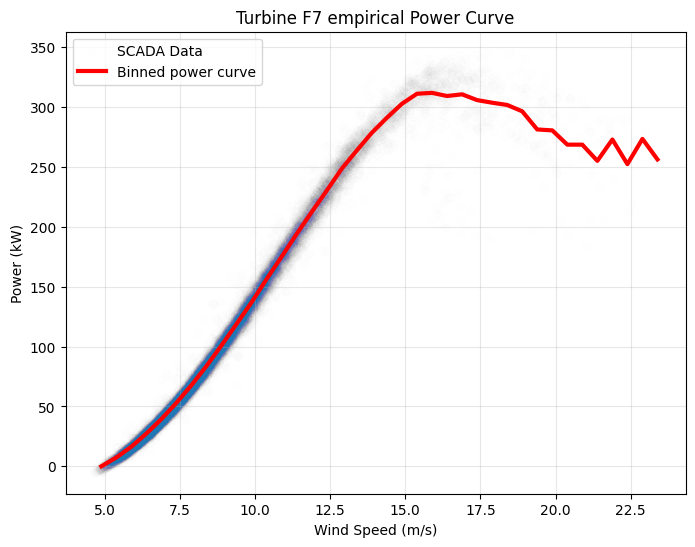

In [8]:
plt.figure(figsize=(8,6))

# Scatter
plt.scatter(
    df_clean['f7_wsn'],
    df_clean['f7_pow'],
    alpha = .005,
    label = 'SCADA Data'
)

# Binned curve
bin_centers = [interval.mid for interval in power_curve.index]

plt.plot(
    bin_centers,
    power_curve.values,
    color='red',
    linewidth = 3,
    label = 'Binned power curve'
)

plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (kW)')
plt.title('Turbine F7 empirical Power Curve')

plt.grid(alpha=0.3)
plt.legend()

plt.savefig('../figures/sprint2_f7_empirical_power_curve.png', dpi=300)
plt.show()

Right now redline shows **mean power per bin** but turbines never produce exactly the same power at the same wind speed because of:
- Turbulence
- Yaw misalignment
- Control behaviour
- Wake effects

So uncertainty bands are often used

C:\Users\szczy\AppData\Local\Temp\ipykernel_18820\2286904900.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  power_curve_mean = df_clean.groupby('wind_bin')['f7_pow'].mean()
C:\Users\szczy\AppData\Local\Temp\ipykernel_18820\2286904900.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  power_curve_std = df_clean.groupby('wind_bin')['f7_pow'].std()


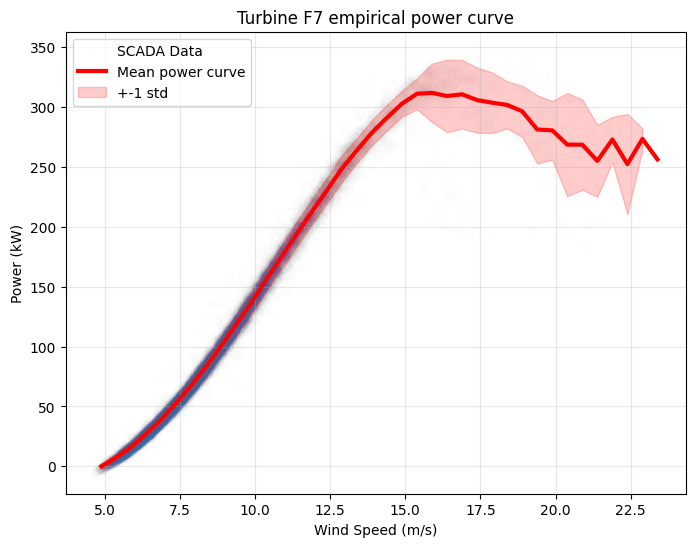

In [9]:
power_curve_mean = df_clean.groupby('wind_bin')['f7_pow'].mean()
power_curve_std = df_clean.groupby('wind_bin')['f7_pow'].std()

# Modifying the plot slightly
bin_centers = [interval.mid for interval in power_curve_mean.index]

plt.figure(figsize=(8,6))

plt.scatter(
    df_clean['f7_wsn'],
    df_clean['f7_pow'],
    alpha=.005,
    label='SCADA Data'
)

plt.plot(
    bin_centers,
    power_curve_mean,
    color='red',
    linewidth = 3,
    label = 'Mean power curve'
)

plt.fill_between(
    bin_centers,
    power_curve_mean - power_curve_std,
    power_curve_mean + power_curve_std,
    color = 'red',
    alpha = .2,
    label = '+-1 std'
)

plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (kW)')
plt.title('Turbine F7 empirical power curve')
plt.grid(alpha=.3)
plt.legend()


plt.savefig('../figures/sprint2_turbine_f7_empirical_power_curve_std.png', dpi=300)
plt.show()

### Additional supporting plots

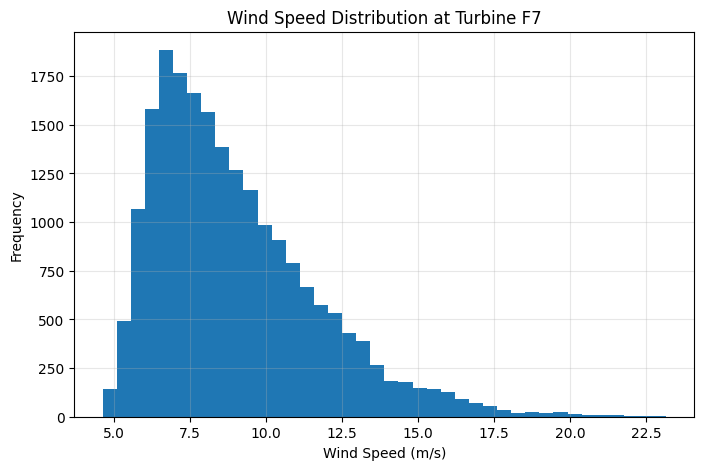

In [10]:
plt.figure(figsize=(8,5))

plt.hist(
    df_clean['f7_wsn'],
    bins = 40
)

plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Frequency')
plt.title('Wind Speed Distribution at Turbine F7')

plt.grid(alpha=0.3)

plt.savefig('../figures/sprint2_wind_speed_distribution_f7_histogram.png', dpi=300)
plt.show()

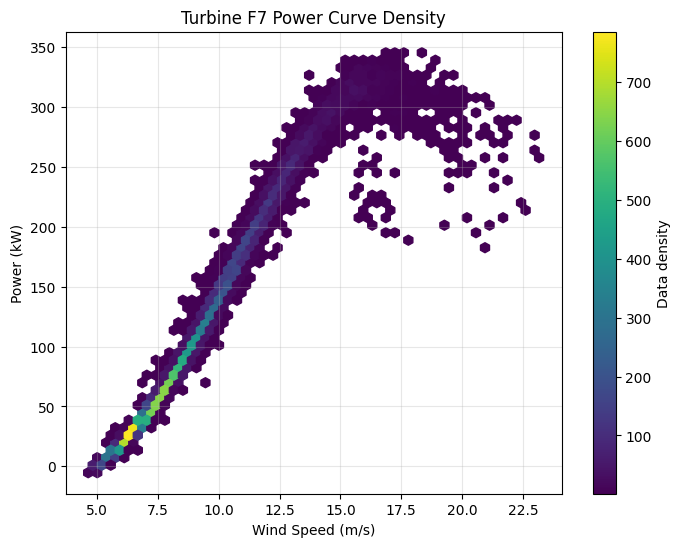

In [11]:
plt.figure(figsize=(8,6))
plt.hexbin(
    df_clean['f7_wsn'],
    df_clean['f7_pow'],
    gridsize=50,
    cmap='viridis',
    mincnt=1
)

plt.colorbar(label='Data density')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (kW)')
plt.title('Turbine F7 Power Curve Density')


plt.savefig('../figures/sprint2_turbine_f7_power_curve_density.png', dpi=300)
plt.grid(alpha=0.3)
plt.show()

C:\Users\szczy\AppData\Local\Temp\ipykernel_18820\2281461339.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['expected_power'] = df_clean['wind_bin'].map(power_curve_mean)
C:\Users\szczy\AppData\Local\Temp\ipykernel_18820\2281461339.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["expected_power"] = df_clean["wind_bin"].map(power_curve_mean)
C:\Users\szczy\AppData\Local\Temp\ipykernel_18820\2281461339.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

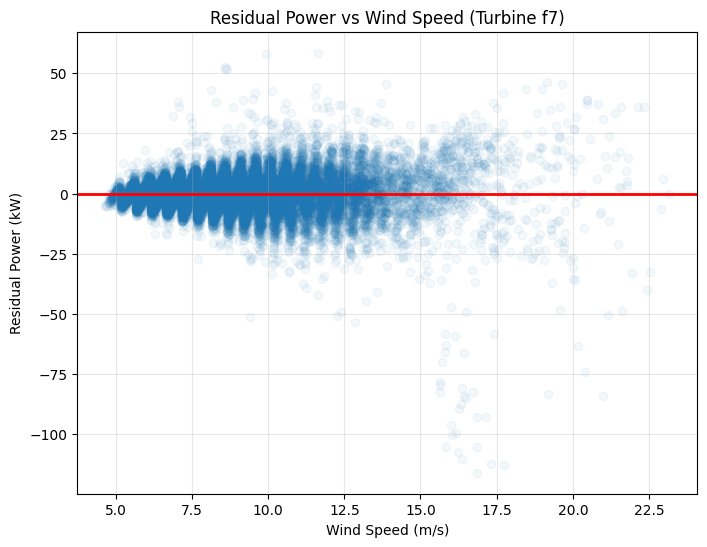

In [12]:
# Map expected power to each bin
df_clean['expected_power'] = df_clean['wind_bin'].map(power_curve_mean)

# Compute residual
df_clean["expected_power"] = df_clean["wind_bin"].map(power_curve_mean)
df_clean["expected_power"] = df_clean["expected_power"].astype(float)

df_clean["residual"] = df_clean["f7_pow"] - df_clean["expected_power"]
# Plot residual vs wind speed
plt.figure(figsize=(8,6))

plt.scatter(
    df_clean['f7_wsn'],
    df_clean['residual'],
    alpha=.05
)

plt.axhline(0, color='red', linewidth=2)

plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Residual Power (kW)')
plt.title('Residual Power vs Wind Speed (Turbine f7)')
plt.grid(alpha=.3)

plt.savefig('../figures/sprint2_residual_power_vs_wind_speed_f7.png', dpi=300)
plt.show()